# %% Cell 1: Dataset Loading and Dimensions 

In [8]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path configuration
file_path = r"D:\ML from Scratch\week1-rls-heart-disease\data\heart.csv" 

# Load dataset
df = pd.read_csv(file_path)
print("✅ Dataset successfully loaded!")

# Get dimensions
n_samples, n_features = df.shape
print(f"Dataset dimensions: Samples (Lines) = {n_samples}, Features (Columns) = {n_features}")

# Preview data
print("\nFirst 5 rows of the dataset:")
print(df.head())

✅ Dataset successfully loaded!
Dataset dimensions: Samples (Lines) = 569, Features (Columns) = 33

First 5 rows of the dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0

# %% Cell 2: Missing Values Verification

In [9]:
# %%
# Check for missing values (NaN) in each column
missing_values = df.isnull().sum()

print(f"🔍 Number of missing values per feature:{missing_values}")


🔍 Number of missing values per feature:id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0


# %% Cell 3: Target Class Distribution (Plot 1)

Class breakdown (M = Malignant, B = Benign):
 diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18668\3465868582.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="coolwarm", edgecolor='k')


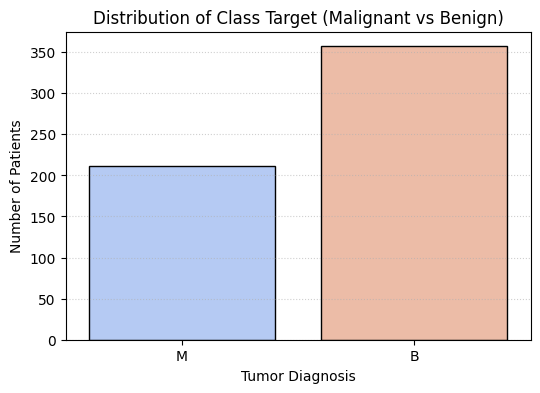

In [10]:
# %%
# Define your target column name based on your output
target_col = 'diagnosis'

# Check the unique values and counts in your target column
class_counts = df[target_col].value_counts()
print("Class breakdown (M = Malignant, B = Benign):\n", class_counts)

# --- TODO: COMPLETE THE PLOT ---
plt.figure(figsize=(6, 4))

# TODO: Replace the 'None' fields with target_col and df
sns.countplot(x=target_col, data=df, palette="coolwarm", edgecolor='k')

plt.title("Distribution of Class Target (Malignant vs Benign)", fontsize=12)
plt.xlabel("Tumor Diagnosis")
plt.ylabel("Number of Patients")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

# %% Cell 4: Feature Distribution (Mean Radius)

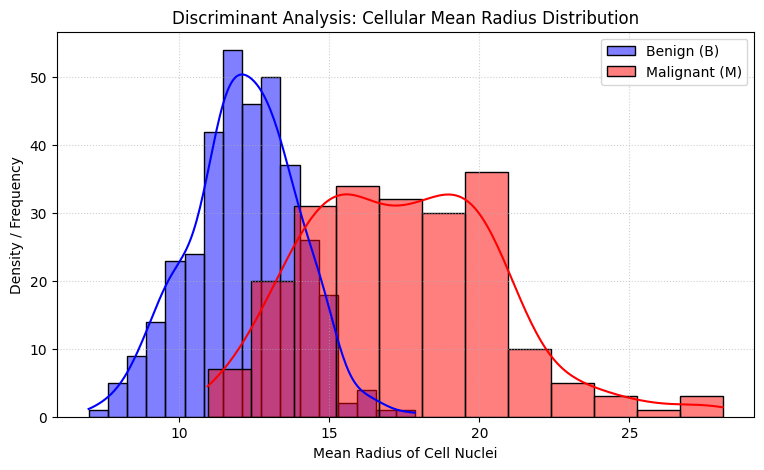

In [11]:
# %%
# --- TODO: COMPLETE THE PLOT ---
plt.figure(figsize=(9, 5))
target_col = "diagnosis"
# Set the correct column strings
feature_col = 'radius_mean'
target_col = 'diagnosis'

# TODO: Fill in the missing 'x' parameters with your feature_col variable
sns.histplot(data=df[df[target_col] == 'B'], x=feature_col, color='blue', label='Benign (B)', kde=True, alpha=0.5)
sns.histplot(data=df[df[target_col] == 'M'], x=feature_col, color='red', label='Malignant (M)', kde=True, alpha=0.5)

plt.title("Discriminant Analysis: Cellular Mean Radius Distribution", fontsize=12)
plt.xlabel("Mean Radius of Cell Nuclei")
plt.ylabel("Density / Frequency")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# %% Cell 5: Correlation Analysis

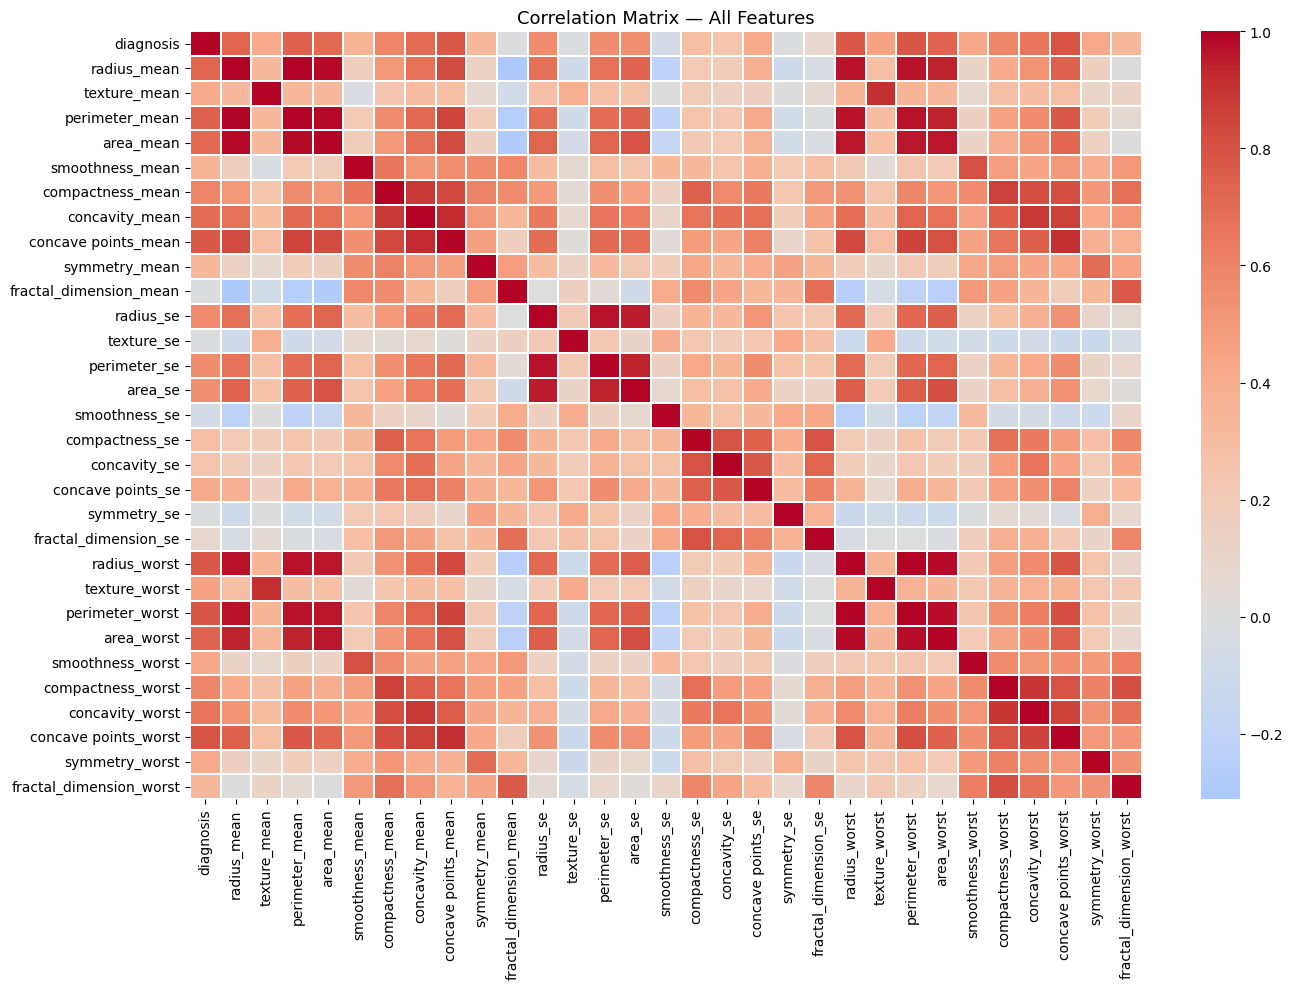

Top 10 features les plus corrélées avec diagnosis :
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


In [12]:

# ── Nettoyer le dataset ───────────────────────────────────────────────────
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

# ── Heatmap de corrélation ────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title("Correlation Matrix — All Features", fontsize=13)
plt.tight_layout()
plt.savefig(r"D:\ML from Scratch\week1-rls-heart-disease\figures\feature_analysis.png", dpi=120)
plt.show()

# ── Top features corrélées avec diagnosis ─────────────────────────────────
top_corr = corr_matrix['diagnosis'].abs().sort_values(ascending=False)[1:11]
print("Top 10 features les plus corrélées avec diagnosis :")
print(top_corr)

# %% Cell 6: Basic Statistics

In [13]:
print("=== Descriptive Statistics ===\n")
print(df_clean.describe().T[['mean','std','min','max']].round(3))

print(f"\nClass 0 (Benign)    : {(df_clean['diagnosis']==0).sum()} patients")
print(f"Class 1 (Malignant) : {(df_clean['diagnosis']==1).sum()} patients")
print(f"Imbalance Ratio     : {(df_clean['diagnosis']==0).sum()/(df_clean['diagnosis']==1).sum():.2f}")

=== Descriptive Statistics ===

                            mean      std      min       max
diagnosis                  0.373    0.484    0.000     1.000
radius_mean               14.127    3.524    6.981    28.110
texture_mean              19.290    4.301    9.710    39.280
perimeter_mean            91.969   24.299   43.790   188.500
area_mean                654.889  351.914  143.500  2501.000
smoothness_mean            0.096    0.014    0.053     0.163
compactness_mean           0.104    0.053    0.019     0.345
concavity_mean             0.089    0.080    0.000     0.427
concave points_mean        0.049    0.039    0.000     0.201
symmetry_mean              0.181    0.027    0.106     0.304
fractal_dimension_mean     0.063    0.007    0.050     0.097
radius_se                  0.405    0.277    0.112     2.873
texture_se                 1.217    0.552    0.360     4.885
perimeter_se               2.866    2.022    0.757    21.980
area_se                   40.337   45.491    6.802   